## Computational Astrobiology – Project Dataset Generation

### Preamble – Importing & Reading

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import clear_output

import json
import yaml

import copy
import os
import subprocess
import sys
import time

import tempfile
import h5py

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['olivedrab', 'steelblue', 'firebrick', 'goldenrod'])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (0, 0)
plt.rcParams['figure.figsize'] = [6,4]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

template_file = 'PSLS/examples/psls.yaml'

with open(template_file, 'r') as file:
    config_dict = yaml.safe_load(file)
    print(json.dumps(config_dict, indent=4, sort_keys=False))

{
    "Observation": {
        "QuarterDuration": [
            90.0,
            90.0,
            90.0
        ],
        "MasterSeed": 1704040900,
        "Gaps": {
            "Enable": 1,
            "Seed": -1,
            "InterQuarterGapDuration": 3.0,
            "RandomGapDuration": 0.0,
            "RandomGapTimeFraction": 0.5,
            "RandomGapStep": 0.0,
            "PeriodicGapCadence": 5.0,
            "PeriodicGapDuration": 20.0,
            "PeriodicGapJitter": 2.0,
            "PeriodicGapStep": 0.0
        }
    },
    "Instrument": {
        "Sampling": 25.0,
        "IntegrationTime": 21.0,
        "GroupID": [
            1,
            2,
            3,
            4
        ],
        "NCamera": 6,
        "TimeShift": 6.25,
        "RandomNoise": {
            "Enable": 1,
            "Type": "PLATO_SIMU",
            "NSR": 73.0
        },
        "Systematics": {
            "Enable": 1,
            "Table": "systematics/PLATO_systematics_BOL_V2.npy",
  

### Template Dictionary

In [14]:
psls_template = {
    'Observation': {
        'QuarterDuration': [90.0] * 16, # days
        'MasterSeed': 0,
        'Gaps': {
            'Enable': 1,
            'Seed': -1,
            'InterQuarterGapDuration': 3.0, # days
            'RandomGapDuration': 20.0, # minutes
            'RandomGapTimeFraction': 0.01,
            'RandomGapStep': 0.0,
            'PeriodicGapCadence': 5.0, # days
            'PeriodicGapDuration': 20.0, # minutes
            'PeriodicGapJitter': 2.0,
            'PeriodicGapStep': 0.0
        }
    },
    'Instrument': {
        'Sampling': 300.0, # seconds
        'IntegrationTime': 252.0, # seconds
        'GroupID': [1, 2, 3, 4],
        'NCamera': 6,
        'TimeShift': 6.25, # seconds
        'RandomNoise': {
            'Enable': 1,
            'Type': 'PLATO_SIMU',
            'NSR': 73.0
        },
        'Systematics': {
            'Enable': 1,
            'Table': 'systematics/PLATO_systematics_BOL_V2.npy',
            'Version': 2,
            'DriftLevel': 'any',
            'Seed': -1
        }
    },
    'Star': {
        'Mag': 10.0,
        'ID': 0,
        'ModelType': 'grid',
        'ModelDir': 'models/',
        'ModelName': 'grid.hdf5',
        'ES': 'ms',
        'Teff': 5772.0,
        'Logg': 4.438,
        'SurfaceRotationPeriod': 0.0,
        'CoreRotationFreq': 0.0,
        'Inclination': 0.0
    },
    'Oscillations': {
        'Enable': 1,
        'numax': 179.3,
        'delta_nu': 13.68,
        'DPI': 80.58,
        'q': 0.15,
        'SurfaceEffects': 1,
        'Seed': -1
    },
    'Activity': {
        'Enable': 1,
        'Sigma': 40.0,
        'Tau': 0.2,
        'Seed': -1,
        'Spot': {
            'Enable': 0,
            'dOmega': 0.0,
            'MuStar': 0.59,
            'MuSpot': 0.78,
            'Radius': [2.5, 2.5, 2.5],
            'Latitude': [0.0, 20.0, 40.0],
            'Longitude': [0.0, 0.0, 0.0],
            'Lifetime': [10, 30, 50],
            'TimeMax': [-1, -1, -1],
            'Contrast': [0.7, 0.8, 0.6],
            'Modulation': 0.0,
            'Seed': -1
        },
        'Flare': {
            'Enable': 0,
            'MeanPeriod': 2,
            'Amplitude': 2500.0,
            'UpDown': 0.1,
            'MeanDuration': -1,
            'DurationDispersion': -1,
            'Seed': -1
        }
    },
    'Granulation': {
        'Enable': 1,
        'Type': 1,
        'Seed': -1
    },
    'Transit': {
        'Enable': 1,
        'PlanetRadius': 0.5,
        'OrbitalPeriod': 10.0,
        'PlanetSemiMajorAxis': 1.0,
        'OrbitalAngle': 0.0,
        'LimbDarkeningCoefficients': [0.25, 0.75]
    },
    'External': {
        'Enable': 0,
        'FilePath': 'examples/external_example.txt'
    }
}

### Auxiliary Functions

In [3]:
def initialize(file_name, total_sims, date_string):
    with h5py.File(file_name, 'x') as f:
        f.attrs['description'] = f'Batch Simulation Results ({total_sims} Runs)'
        f.attrs['date_created'] = date_string
        f.attrs['user'] = 'Fritz Ali Agildere'

def run(temp_file):
    %cd -q PSLS
    !echo '' | ./psls.py -o data {temp_file.name}
    %cd -q ..

def save(i, file_name, group_name, temp_file):
    with h5py.File(file_name, 'a') as f:
        run = f.create_group(group_name)
        
        with open(temp_file.name, 'r') as cfg:
            run.attrs['config_used'] = cfg.read()

        with open(f'PSLS/data/{i:010d}.txt', 'r') as txt:
            content = txt.read()
            dt = h5py.string_dtype(encoding='utf-8')
            run.create_dataset('txt', data=content, dtype=dt)
            
        dat = f[group_name].create_group('dat')
        time_s, flux_var_ppm, flag = np.genfromtxt(f'PSLS/data/{i:010d}.dat', unpack=True, skip_header=5)
        
        dat.create_dataset('time_s', data=time_s, compression='gzip', shuffle=True)
        dat.create_dataset('flux_var_ppm', data=flux_var_ppm, compression='gzip', shuffle=True)
        dat.create_dataset('flag', data=flag, compression='gzip', shuffle=True)
        
        modes = f[group_name].create_group('modes')
        n, l, m, nu, gamma, h, I_Imax, dnu, split = np.genfromtxt(f'PSLS/data/{i:010d}.modes', unpack=True, skip_header=1)
        
        modes.create_dataset('n', data=n, compression='gzip', shuffle=True)
        modes.create_dataset('l', data=l, compression='gzip', shuffle=True)
        modes.create_dataset('m', data=m, compression='gzip', shuffle=True)
        modes.create_dataset('nu', data=nu, compression='gzip', shuffle=True)
        modes.create_dataset('gamma', data=gamma, compression='gzip', shuffle=True)
        modes.create_dataset('h', data=h, compression='gzip', shuffle=True)
        modes.create_dataset('I_Imax', data=I_Imax, compression='gzip', shuffle=True)
        modes.create_dataset('dnu', data=dnu, compression='gzip', shuffle=True)
        modes.create_dataset('split', data=split, compression='gzip', shuffle=True)

def clean(i):
    txt = f'PSLS/data/{i:010d}.txt'
    dat = f'PSLS/data/{i:010d}.dat'
    modes = f'PSLS/data/{i:010d}.modes'
    
    %rm {txt}
    %rm {dat}
    %rm {modes}

### Parameter Sampling

In [4]:
def sample(i, config_dict, planet_setting, rng):
    config_dict['Observation']['MasterSeed'] = i
    config_dict['Star']['ID'] = i
    config_dict['Star']['Mag'] = rng.uniform(9.0, 13.0)

    mass = rng.uniform(0.91, 1.19)
    metal = rng.normal(-0.1, 0.2)
#    radius = 
#    config_dict['Star']['']

### Simulation Loop

In [7]:
def simulate(total_sims = 666, initial_state = 0, seed = 123, title='none'):

    rng = np.random.default_rng(seed)

    start_batch = time.time()

    id_str = time.strftime('%Y%m%d%H%M%S', time.gmtime(start_batch))
    attr_str = time.strftime('%d.%m.%Y, %H:%M:%S', time.gmtime(start_batch))

    file_name = f'PSLS/data/{id_str}.hdf5'

    if title != 'none':
        initialize(file_name, total_sims, title)
    else:
        initialize(file_name, total_sims, attr_str)

    initial_status = f'│ progress |{'░' * 50}| 0% [running 1/{total_sims}] (00:00:00/--:--:--)          '
    
    print(f'{initial_status}')
    
    i = initial_state
    while i < total_sims + initial_state:
        
        if i != 0:
            perc = i / total_sims * 100
            bar = '█' * int(perc // 2) + '░' * (50 - int(perc // 2))
            status = f'│ progress |{bar}| {perc:.0f}% [running {i+1}/{total_sims}] ({elapsed_str}/{estimated_str})          '
    
            clear_output(wait=True)
            print(f'{status}')

        config = copy.deepcopy(psls_template)

        sys.stdout.write(f'└── initializing simulation {i + 1}          ')
        sys.stdout.flush()
        sys.stdout.write(f'\r└─┬ initializing simulation {i + 1}          \n')
        sys.stdout.write(f'  └── sampling parameters [active]          ')
        sys.stdout.flush()
        
        sample(i, config, title, rng)
        
        with tempfile.NamedTemporaryFile(suffix='.yaml', dir='PSLS', mode='w', delete=True) as tf:
            yaml.dump(config, tf, default_flow_style=False, sort_keys=False)
            tf.flush()
            
            sys.stdout.write(f'\r  ├── sampling parameters [done]          \n')
            sys.stdout.write(f'  └── generating lightcurve [active]          ')
            sys.stdout.flush()
            
            run(tf)
    
            sys.stdout.write(f'\r  ├── generating lightcurve [done]          \n')
            sys.stdout.write(f'  └── saving dataframe [active]          ')
            sys.stdout.flush()

            group_name = f'run_{i + 1:05d}'

            save(i, file_name, group_name, tf)

            clean(i)

        current_run = time.time()
        
        elapsed_batch = current_run - start_batch
        
        average_time = elapsed_batch / (i + 1)
        
        estimated_batch = elapsed_batch + (total_sims - (i + 1)) * average_time
    
        elapsed_str = time.strftime('%H:%M:%S', time.gmtime(elapsed_batch))
        estimated_str = time.strftime('%H:%M:%S', time.gmtime(estimated_batch))
    
        i += 1

    final_status = f'│ progress |{'█' * 50}| 100% [finished {i}/{total_sims}] ({elapsed_str}/{estimated_str})          '

    clear_output(wait=True)
    print(f'{final_status}')

In [15]:
simulate(5)

│ progress |██████████████████████████████████████████████████| 100% [finished 5/5] (00:00:20/00:00:20)          


In [16]:
with h5py.File('PSLS/data/20260507180707.hdf5', 'r') as f:
    print(f.keys())
    print(f['run_00001'].keys())
    print(f['run_00001/dat'].keys())
    print(f['run_00001/modes'].keys())
    print(f['run_00001/txt'][()].decode('utf-8'))

<KeysViewHDF5 ['run_00001', 'run_00002', 'run_00003', 'run_00004', 'run_00005']>
<KeysViewHDF5 ['dat', 'modes', 'txt']>
<KeysViewHDF5 ['flag', 'flux_var_ppm', 'time_s']>
<KeysViewHDF5 ['I_Imax', 'dnu', 'gamma', 'h', 'l', 'm', 'n', 'nu', 'split']>
StarID = 0000000000
Master_seed = 0
Version =    1.90
# star parameters:
 teff = 5777.294093 ,logg = 4.440133
 mass = 0.955875,  teff = 5777.29,  radius = 0.974745,  logg = 4.44032,  lum = 0.954411,  age = 5765.8
# observations parameters:
 magnitude = 11.7294,  duration = 1440,  sampling = 300,  frequency_resolution = 0.00803755,  nyquist = 1666.67,  white_noise = -60,  time_steps_number = 414720,  bolometric_coefficient = 0.978817
# oscillation parameters:
 numax = 3068.37,  deltanu = 137.151,  Amax = 3.69093,  Hmax = 7.40844,  Gammamax = 1.17064,  width_envelop = 772.722,  se_a = -0.00431338,  se_b = 5.28658
# granulation parameters:
 h1 = 0.762655,  tau1 = 0.00020819,  alpha1 = 4,  h2 = 0.246924,  tau2 = 5.83444e-05,  alpha2 = 4,  taue = 0

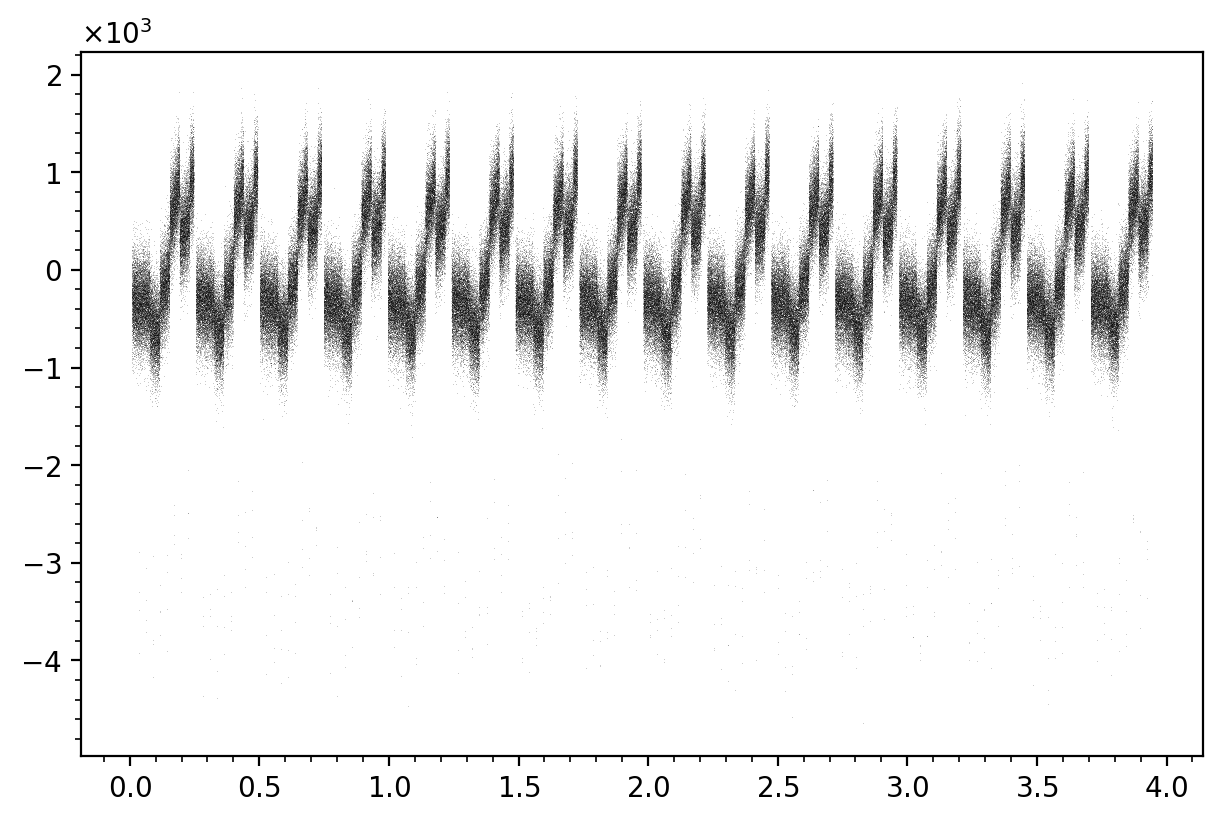

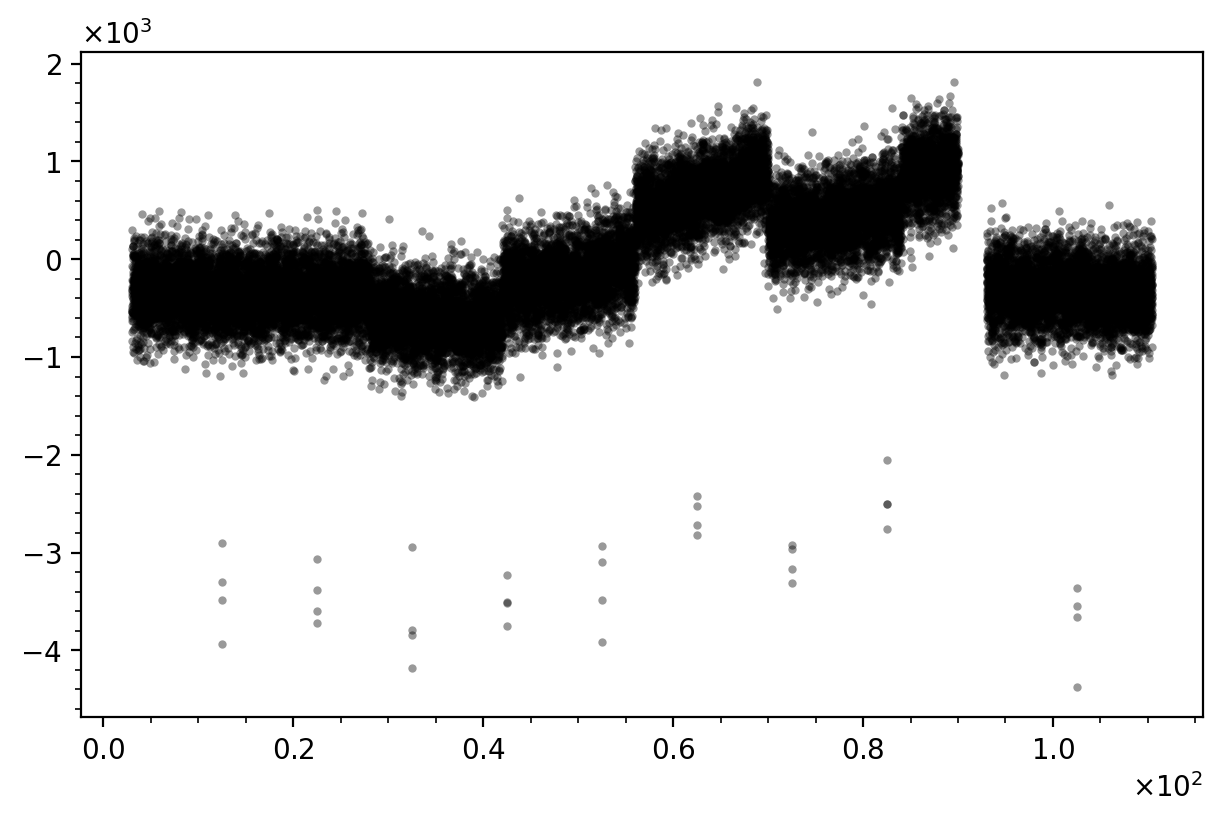

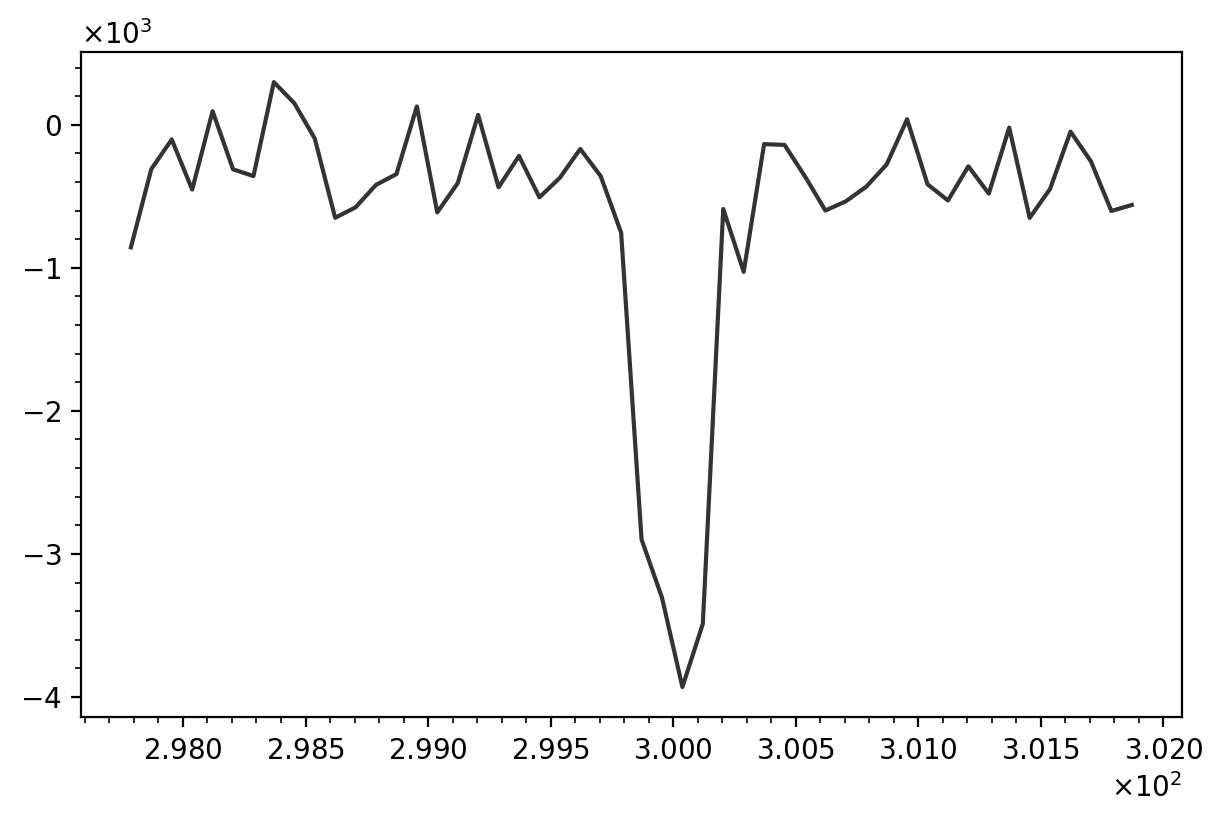

In [17]:
with h5py.File('PSLS/data/20260507180707.hdf5', 'r') as f:
    x = f['run_00001/dat/time_s'][:] / (3600 * 24 * 365)
    y = f['run_00001/dat/flux_var_ppm'][:]
    plt.plot(x, y, 'k,', alpha=0.2)
    plt.show()
    plt.close()
    plt.plot(x[:30000] * (365), y[:30000], 'k.', mec='none', alpha=0.4)
    plt.show()
    plt.close()
    low = 2700
    up = 2750
    plt.plot(x[low:up] * (24 * 365), y[low:up], 'k-', mec='none', alpha=0.8)
    plt.show()
    plt.close()

In [ ]:
15 / 5 * 666

In [ ]:
666 * 4